In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
url = "https://www.who.int/news-room"

In [3]:
headers = {"User-Agent": "Mozilla/5.0"}

In [4]:
response = requests.get(url, headers=headers)

In [5]:
soup = BeautifulSoup(response.text, "html.parser")

In [6]:
items = soup.find_all("a")

health_articles = []
links = []

In [7]:
for item in items:
    text = item.get_text(strip=True)
    href = item.get("href")

    if text:
        links.append(text)

    if "2026" in text or "2025" in text:
        health_articles.append(text)

In [8]:
for article in health_articles[:10]:
    print(article)

30 March 2026Departmental updateMessage from the Director - continuing sexual and reproductive health and rights progress in turbulent times
30 March 2026StatementTypes of data requested to inform May 2026 COVID-19 vaccine antigen composition deliberations
28 March 2026News releaseWHO Member States agree to extend negotiations on key annex to the Pandemic Agreement
26 March 2026Departmental updateWHO welcomes IOM into the Global Digital Health Certification Network
Stronger together: milestones that mattered in 2025
30 March 2026How WHO and AIIMS in New Delhi are working together in support of healthy ageing
24 March 2026WHO Director-General's opening remarks at the Human Reproduction Programme Policy and Coordination Meeting – 24 March 2026
25 November 2025Invisible frontlines: tackling antimicrobial resistance amid conflict and fragility
One Health lessons on arboviruses for stronger preparedness in LMICs31 March 2026 15:00 – 16:30 CET
Shaping the next Global Strategy on Digital Heal

In [9]:
df = pd.DataFrame({"Page": links})

In [10]:
G = nx.Graph()

In [11]:
for item in items[:20]:
    href = item.get("href")
    if href:
        G.add_edge(url, href)

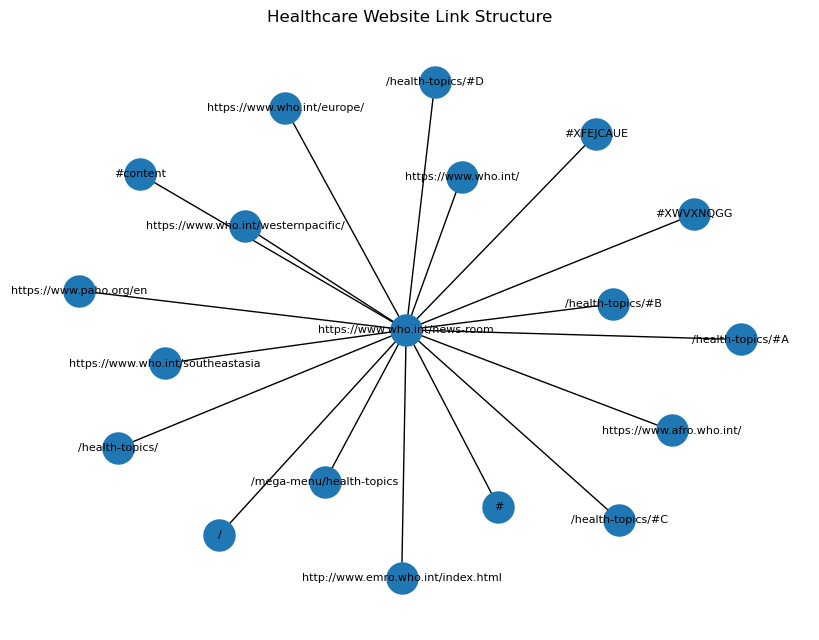

In [12]:
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_size=500, font_size=8)
plt.title("Healthcare Website Link Structure")
plt.show()

In [13]:
page_counts = df["Page"].value_counts().head(10)
print(page_counts)

Page
All →                    7
Europe                   3
Regions                  3
South-East Asia          3
Americas                 3
Western Pacific          3
Eastern Mediterranean    3
Africa                   3
D                        2
B                        2
Name: count, dtype: int64


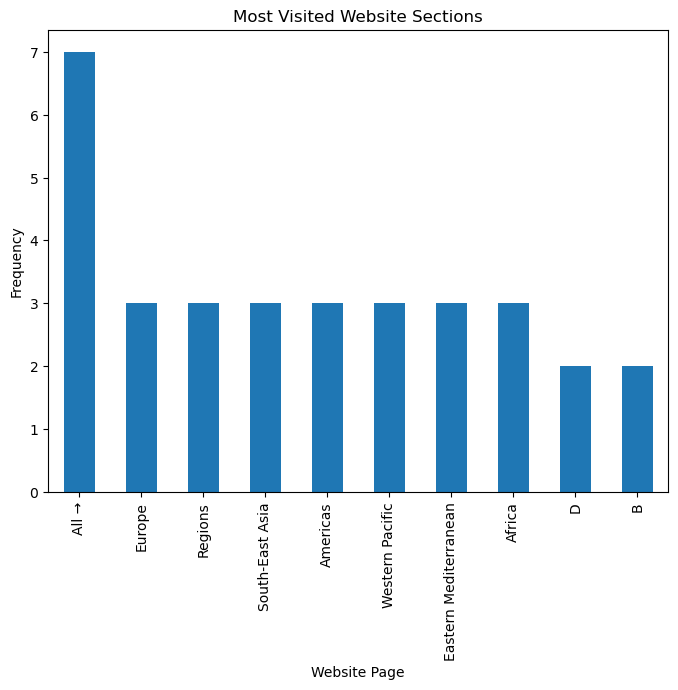

In [14]:
plt.figure(figsize=(8, 6))
page_counts.plot(kind="bar")
plt.title("Most Visited Website Sections")
plt.xlabel("Website Page")
plt.ylabel("Frequency")
plt.show()